In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


# <span style="color:red">ch5. LSTM(Long Short - Term Memory; RNN)으로 영화평 구분하기<span>
- imdb의 5만개 영화 감상평(독립변수) - 부정/긍정(종속변수)

# 1. 패키지 import

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time # 70.1.1부터 현재까지 몇초가 지났는지

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense # Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import pandas as pd

# 2. 하이퍼 파라미터 설정(이 파라미터를 바꾸면 score나 속도에 차이)

In [85]:
MY_WORDS = 10000 # imdb 데이터안의 단어 수
MY_LENGTH = 80 # 영화평 단어수 80개까지만 독립변수(230추천)
MY_EMBED = 32  # 임베딩 layer의 출력 차원(256추천)
MY_HIDDEN = 64 # LSTM의 units수(128추천)
MY_EPOCH = 10 # 반복 학습 수 (fit 20정도 추천)
MY_BATCH = 200 # 매번 가져오는 데이터 수
SKIP_TOP = 40 # 불용어 인덱스 설정(빈도수 상위 40개는 제외 : the, a, is 등)

# 3. 데이터 불러오기

In [9]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=MY_WORDS,
                                                     # skip_top=SKIP_TOP) # MY_WORDS(10000)개

17464789/17464789 [==============================] - 2s 0us/step


In [15]:
print('학습용 데이터 shape :', X_train.shape, y_train.shape)
print('학습용 입력 데이터 샘플 :', X_train[0], '-', type(X_train[0]), '-', len(X_train[0]))
print('학습용 타겟 데이터 샘플(0:부정/1:긍정) :', y_train[0])
print()
print('시험용 데이터 shape :', X_test.shape, y_test.shape)
print('시험용 입력 데이터 샘플 :', X_test[0], '-', type(X_test[0]), '-', len(X_test[0]))
print('시험용 타겟 데이터 샘플(0:부정/1:긍정) :', y_test[0])

학습용 데이터 shape : (25000,) (25000,)
학습용 입력 데이터 샘플 : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32] - <class '

In [22]:
# X_train의 길이 및 평균길이
print([len(x) for x in X_train[:10]])
np.array([len(x) for x in X_train]).mean()

[218, 189, 141, 550, 147, 43, 123, 562, 233, 130]


238.71364

In [24]:
# 부/긍정 개수 확인
print('학습용 데이터의 긍정 개수 :', y_train.sum())
print('테스트용 데이터의 긍정 개수 :', y_test.sum())

학습용 데이터의 긍정 개수 : 12500
테스트용 데이터의 긍정 개수 : 12500


In [27]:
# 부/긍정 개수 확인
pd.Series(y_train).value_counts()#.sort_index()

1    12500
0    12500
dtype: int64

# 4. 문자 단어 → 정수

In [40]:
word_to_id = imdb.get_word_index() # dict (단어:id값) : 빈도수가 높은 단어를 id앞에
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 : 단어 dict
id_to_word = {}
for word, id in word_to_id.items():
    id_to_word[id] = word
print(id_to_word[17])
print(id_to_word[19])
print(id_to_word[1])

17
19
1
movie
film
the


In [39]:
# 감성분성에서 필요없는 조사, 관사가 주로 나옴
print([id_to_word.get(i) for i in range(1, 40)])

['the', 'and', 'a', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'so', 'from', 'like', 'her', 'or']


In [62]:
msg = 'What a wonderful movie'
msg = msg.lower().split() # lower : 소문자로 변경
# 1: 리뷰시작할때 무조건 추가, 2: 문자가 짤려서 잘못 읽어옴, 3: padding처리
data = [1] + [word_to_id.get(m, -1)+3 for m in msg]
print('원 후기 내용 :', msg)
print('encoding된 data :', data)
data_msg = ' '.join([id_to_word.get(d-3, '??') for d in data])
print('data로 추정된 msg :', data_msg)

원 후기 내용 : ['what', 'a', 'wonderful', 'movie']
encoding된 data : [1, 51, 6, 389, 20]
data로 추정된 msg : ?? what a wonderful movie


# 5. 숫자 영화평 → 자연어 영화평 함수

In [70]:
def decoding(review_num):
    "숫자 영화평을 자연어 영화평으로 바꿔 return"
    decoded = [id_to_word.get(d-3, '??') for d in review_num]
    return ' '.join(decoded)
decoding(X_train[0])

"?? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ?? is an amazing actor and now the same being director ?? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ?? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ?? to the two little boy's that played the ?? of norman and paul they were just brilliant children are often left out of the ?? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't

# 6. 영화평 데이터 처음 5개 길이 출력 함수

In [73]:
def show_length(X_train=X_train):
    print('첫 데이터 5개 영화평 단어 길이')
    for i in range(5):
        print(f'{i}번째 길이 : {len(X_train[i])}')

show_length()

첫 데이터 5개 영화평 단어 길이
0번째 길이 : 218
1번째 길이 : 189
2번째 길이 : 141
3번째 길이 : 550
4번째 길이 : 147


In [74]:
print('pad sequence 작업 전')
show_length(X_train)
show_length(X_test)

pad sequence 작업 전
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 218
1번째 길이 : 189
2번째 길이 : 141
3번째 길이 : 550
4번째 길이 : 147
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 68
1번째 길이 : 260
2번째 길이 : 603
3번째 길이 : 181
4번째 길이 : 108


In [75]:
# 영화평 단어길이 최대값과 최소값
max(len(x) for x in X_train), min(len(x) for x in X_train)

(2494, 11)

# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)

In [76]:
MY_LENGTH

80

In [78]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [79]:
X_train = pad_sequences(
    X_train,
    maxlen=MY_LENGTH,
    truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
    # truncating='pre',
    padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
    #padding='post'
)
X_test = pad_sequences(
    X_test,
    maxlen=MY_LENGTH,
    truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
    # truncating='pre',
    padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
    #padding='post'
)
show_length(X_train)
show_length(X_test)

첫 데이터 5개 영화평 단어 길이
0번째 길이 : 80
1번째 길이 : 80
2번째 길이 : 80
3번째 길이 : 80
4번째 길이 : 80
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 80
1번째 길이 : 80
2번째 길이 : 80
3번째 길이 : 80
4번째 길이 : 80


In [83]:
X_test[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    1,  591,  202,   14,   31,    6,  717,   10,   10,    2,
          2,    5,    4,  360,    7,    4,  177, 5760,  394,  354,    4,
        123,    9, 1035, 1035, 1035,   10,   10,   13,   92,  124,   89,
        488, 7944,  100,   28, 1668,   14,   31,   23,   27, 7479,   29,
        220,  468,    8,  124,   14,  286,  170,    8,  157,   46,    5,
         27,  239,   16,  179,    2,   38,   32,   25, 7944,  451,  202,
         14,    6,  717])

In [84]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

# 9. 모델 생성 구현

In [91]:
model = Sequential(name='sequential')
model.add(Embedding(input_dim=MY_WORDS, # 임베딩 입력 : 10000
                                        output_dim=MY_EMBED, # 임베딩 출력 : 32
                                        input_length=MY_LENGTH)) # 입력 단어 수 : 80

# RNN은 장기 과거 시점의 모델 학습이 어려움. 길이가 길어질수록 과거 학습에 어려움이 발생.
# RNN 개선모델 1. LSTM 2.GRU
model.add(LSTM(units=MY_HIDDEN, # 출력 units
              dropout=0.3, # 0.2 ~ 0.5 각 스텝마다 LSTM셀로 들어가는 X 연결 30%를 0으로
              recurrent_dropout=0.2, # GPU 안씀. 0.1~0.3 이전 LSTM에서 다음 LSTM으로 가는 C연결 30%를 0으로
              kernel_regularizer=l2(0.001), # L2규제
              recurrent_regularizer=l2(0.001), # 순환가중치 L2가중치
              kernel_initializer='he_normal', # 입력 가중치 초기화를 he방법으로
              recurrent_initializer='orthogonal')) # 순환가중치 초기화
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# embedding 층 : 파라미터 입력*출력 = 10000*32
# LSTM 층 : 입력*출력 + (64*64) + unit수(bias) = [(32*64) + (64*64) + 64] * 4(LSTM은 게이트가 4)
#                                                                        = (2048+4096+64)*4
# Dense층 : 입력*출력 + 출력 = 64*1+1 = 65

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 80, 32)            320000    
                                                                 
 lstm_2 (LSTM)               (None, 64)                24832     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 344,897
Trainable params: 344,897
Non-trainable params: 0
_________________________________________________________________


# 10. 학습설정 및 학습하기

In [93]:
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['acc'])
begin = time() # 70.1.1부터 현재까지의 초수
earlyStopping = EarlyStopping(monitor='val_loss',
                             patience=3,
                             mode='min',
                             restore_best_weights=True, # 멈췄을 경우, val_loss가 가장 낮았던 시점의 가중치로 복원
                             verbose=1) # 언제 멈췄는지 로그 출력
hist = model.fit(X_train, y_train,
                validation_split=0.2,
                epochs=MY_EPOCH,
                batch_size=MY_BATCH,
                verbose=2,
                callbacks=[earlyStopping])
end = time()
print(f'총 학습 시간 : {end-begin:.2f}초')

Epoch 1/10
100/100 - 16s - loss: 0.2875 - acc: 0.9089 - val_loss: 0.4869 - val_acc: 0.8088 - 16s/epoch - 160ms/step
Epoch 2/10
100/100 - 13s - loss: 0.2423 - acc: 0.9220 - val_loss: 0.5148 - val_acc: 0.8060 - 13s/epoch - 128ms/step
Epoch 3/10
100/100 - 14s - loss: 0.2237 - acc: 0.9284 - val_loss: 0.5942 - val_acc: 0.8036 - 14s/epoch - 141ms/step
Epoch 4/10
Restoring model weights from the end of the best epoch: 1.
100/100 - 14s - loss: 0.2056 - acc: 0.9349 - val_loss: 0.5258 - val_acc: 0.8046 - 14s/epoch - 143ms/step
Epoch 4: early stopping
총 학습 시간 : 57.24초


# 11. 모델 평가

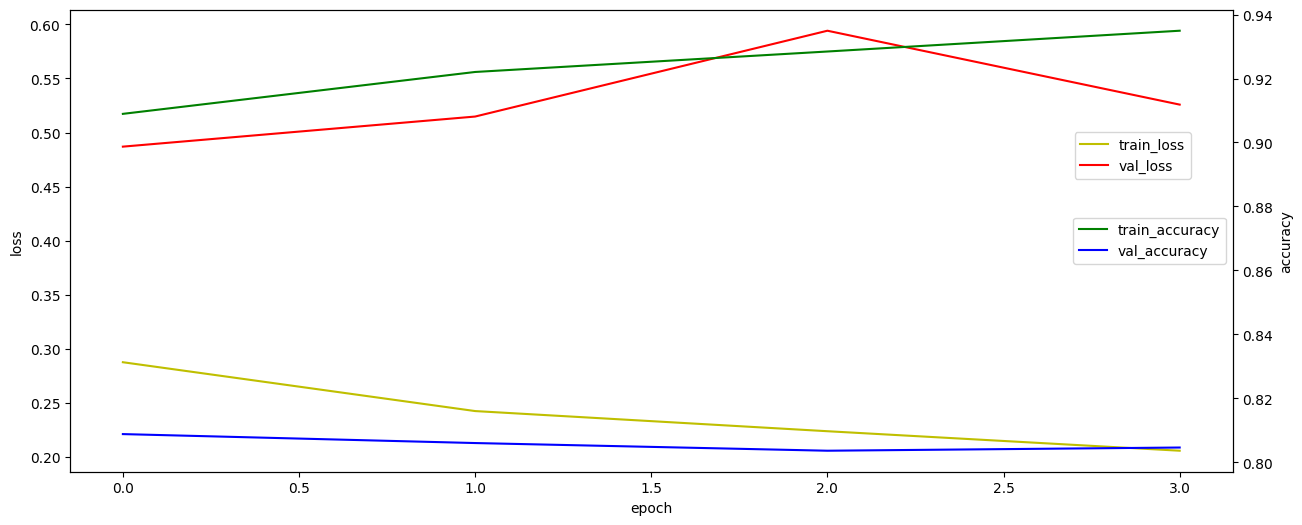

In [97]:
# 모델 학습과정 시각화
# 학습과정 살펴보기(시각화)
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_acc'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [99]:
loss, acc = model.evaluate(X_test, y_test, 
                           batch_size=MY_BATCH # batch_size 기본값이 32
                          )
print('test데이터의 정확도 :', acc)

125/125 [==============================] - 5s 36ms/step - loss: 0.5485 - acc: 0.7840
test데이터의 정확도 : 0.7840399742126465


In [102]:
# 혼돈행렬, recall_score, precision_score, f1_score 계산을 위한 예측값
pred = model.predict(X_test, batch_size=MY_BATCH)
y_hat = (pred>0.5).astype(int)
y_hat # 2차원

125/125 [==============================] - 4s 36ms/step


array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [1]])

In [104]:
confusion_matrix(y_test, y_hat)

array([[9617, 2883],
       [2516, 9984]], dtype=int64)

In [105]:
pd.crosstab(y_test, y_hat.reshape(-1))

col_0,0,1
row_0,,
0,9617,2883
1,2516,9984


In [111]:
'''
accuracy(정확도) = (TN+TP) / 전체수(TN+FP_FN+TP)
precision(정밀도) = TP / 예측을 1이라고 한 수 (FP+TP)
        예측값 기준
recall(재현율=민감도) = TP / 실제가 1인 수 (FN+TP)
        실제값 기준
f1 score = recall과 precision의 조화평균
        2 * (precision*recall) / (precision+recall)
'''
print('recall :', recall_score(y_test, y_hat))
print('precision :', precision_score(y_test, y_hat))
print('f1-score :', f1_score(y_test, y_hat))
print('acc :', acc)

recall : 0.79872
precision : 0.7759384471904873
f1-score : 0.7871644262230457
acc : 0.7840399742126465


# 12. 모델사용하기

In [124]:
review = '''
I had thought Interstellar was just a simple space film, but after watching it,
I felt it was a work that makes you reflect on family, time, and human choice. In particular,
the emotions the protagonist experiences as he leaves his family and embarks on a journey into space were striking.
Watching the scene where time, which feels like only a few years pass on Earth, flows through another space as a much longer duration,
I began to think about how deeply time means to people. I was also struck by how, even in difficult circumstances, 
he never gave up and chose to trust his own decisions and keep moving forward. 
Although some of the film’s scientific settings felt somewhat difficult to follow, 
the beautiful visuals and music blended together so well that I was able to watch it with great immersion. Overall, I felt that it was a work that,
rather than being just a movie for entertainment, made me reflect on many things even after watching it.
'''
import re
review = re.sub('[^a-zA-Z\s]', ' ', review).split()
review_num = [1] + [word_to_id.get(word, -1)+3 for word in review]
review_num = [num if (num>0) & (num<10000) else 2 for num in review_num]
print(review)
print(review_num)

['I', 'had', 'thought', 'Interstellar', 'was', 'just', 'a', 'simple', 'space', 'film', 'but', 'after', 'watching', 'it', 'I', 'felt', 'it', 'was', 'a', 'work', 'that', 'makes', 'you', 'reflect', 'on', 'family', 'time', 'and', 'human', 'choice', 'In', 'particular', 'the', 'emotions', 'the', 'protagonist', 'experiences', 'as', 'he', 'leaves', 'his', 'family', 'and', 'embarks', 'on', 'a', 'journey', 'into', 'space', 'were', 'striking', 'Watching', 'the', 'scene', 'where', 'time', 'which', 'feels', 'like', 'only', 'a', 'few', 'years', 'pass', 'on', 'Earth', 'flows', 'through', 'another', 'space', 'as', 'a', 'much', 'longer', 'duration', 'I', 'began', 'to', 'think', 'about', 'how', 'deeply', 'time', 'means', 'to', 'people', 'I', 'was', 'also', 'struck', 'by', 'how', 'even', 'in', 'difficult', 'circumstances', 'he', 'never', 'gave', 'up', 'and', 'chose', 'to', 'trust', 'his', 'own', 'decisions', 'and', 'keep', 'moving', 'forward', 'Although', 'some', 'of', 'the', 'film', 's', 'scientific', '

In [119]:
input_data =pad_sequences([review],
        maxlen=MY_LENGTH,
        truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
        padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
)
input_data.shape

(1, 80)

In [120]:
(model.predict(input_data)>0.5).astype('int')

1/1 [==============================] - 0s 27ms/step


array([[1]])

In [128]:
review = '''
I had thought Interstellar was just a simple space film, but after watching it,
I felt it was a work that makes you reflect on family, time, and human choice. In particular,
the emotions the protagonist experiences as he leaves his family and embarks on a journey into space were striking.
Watching the scene where time, which feels like only a few years pass on Earth, flows through another space as a much longer duration,
I began to think about how deeply time means to people. I was also struck by how, even in difficult circumstances, 
he never gave up and chose to trust his own decisions and keep moving forward. 
Although some of the film’s scientific settings felt somewhat difficult to follow, 
the beautiful visuals and music blended together so well that I was able to watch it with great immersion. Overall, I felt that it was a work that,
rather than being just a movie for entertainment, made me reflect on many things even after watching it.
'''.lower()
import re

# 특수문자 제거 + 단어 단위로 분리
review = re.sub('[^a-zA-Z\s]', ' ', review).split()
# 단어 → 숫자 ID
review_num = [1] + [word_to_id.get(word, -1) + 3 for word in review]

# ID 범위 제한
review_num = [
    num if (num > 0) & (num < 10000) else 2
    for num in review_num ]
print(review_num)

# 80개 길이로 맞추기
input_data = pad_sequences(
    [review_num],
    maxlen=MY_LENGTH,
    truncating='post',
    padding='pre'
)
# 영화 리뷰 긍정/부정 예측
prediction = (model.predict(input_data) > 0.5).astype('int')
print(prediction)

[1, 13, 69, 197, 2, 16, 43, 6, 606, 834, 22, 21, 103, 149, 12, 13, 421, 12, 16, 6, 157, 15, 166, 25, 4589, 23, 223, 58, 5, 406, 1099, 11, 843, 4, 1438, 4, 2311, 2490, 17, 29, 889, 27, 223, 5, 2, 23, 6, 1311, 83, 834, 71, 3347, 149, 4, 136, 121, 58, 63, 764, 40, 64, 6, 171, 153, 1345, 23, 703, 7900, 143, 160, 834, 17, 6, 76, 1207, 5936, 13, 1695, 8, 104, 44, 89, 1685, 58, 817, 8, 84, 13, 16, 82, 3502, 34, 89, 60, 11, 878, 2331, 29, 115, 520, 56, 5, 2471, 8, 1684, 27, 205, 4145, 5, 401, 728, 930, 261, 49, 7, 4, 22, 590, 3749, 2775, 421, 643, 878, 8, 794, 4, 307, 2057, 5, 228, 2, 295, 38, 73, 15, 13, 16, 502, 8, 106, 12, 19, 87, 2, 444, 13, 421, 15, 12, 16, 6, 157, 15, 247, 74, 112, 43, 6, 20, 18, 722, 93, 72, 4589, 23, 111, 183, 60, 103, 149, 12]
1/1 [==============================] - 0s 32ms/step
[[1]]
